# Experiment 1: Descriptive and Inferential Statistics

## Case Study: Customer Segmentation (Online Retail Dataset)

### **AIM**
To explore and analyze descriptive and inferential statistics on the Online Retail dataset for Customer Segmentation, and to visualize the data using various statistical plots.

---

### **THEORY**

### A) Descriptive Statistics

Descriptive statistics summarize and organize characteristics of a dataset. They provide simple summaries about the sample and the measures.

| **Statistic** | **Definition** | **Formula** |
|---|---|---|
| **Mean** | Average of all values | $\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$ |
| **Median** | Middle value when data is sorted | Middle value of sorted data; if $n$ is even: $\frac{x_{n/2} + x_{n/2+1}}{2}$ |
| **Mode** | Most frequently occurring value | Value with highest frequency |
| **Min** | Smallest value in dataset | $x_{min} = \min(x_1, x_2, ..., x_n)$ |
| **Max** | Largest value in dataset | $x_{max} = \max(x_1, x_2, ..., x_n)$ |
| **Sum** | Total of all values | $S = \sum_{i=1}^{n} x_i$ |
| **Range** | Difference between max and min | $R = x_{max} - x_{min}$ |
| **First Quartile (Q1)** | Value below which 25% of data falls | 25th percentile |
| **Third Quartile (Q3)** | Value below which 75% of data falls | 75th percentile |
| **Interquartile Range (IQR)** | Spread of the middle 50% | $IQR = Q3 - Q1$ |
| **Standard Deviation** | Measure of data dispersion | $\sigma = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}}$ |
| **Variance** | Square of standard deviation | $\sigma^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$ |
| **Correlation** | Linear relationship between two variables | $r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$ |
| **SE of Mean** | Standard error of the mean | $SE = \frac{\sigma}{\sqrt{n}}$ |
| **Coefficient of Variation** | Relative variability | $CV = \frac{\sigma}{\bar{x}} \times 100$ |
| **N Missing** | Count of missing values | Count of NaN/null entries |
| **N Total** | Total number of observations | $N$ |
| **Cumulative N** | Running total of frequencies | $C_k = \sum_{i=1}^{k} f_i$ |
| **Percent** | Proportion as percentage | $P_i = \frac{f_i}{N} \times 100$ |
| **Cumulative Percent** | Running total of percentages | $CP_k = \sum_{i=1}^{k} P_i$ |
| **Trimmed Mean** | Mean after removing extreme values | Mean of data after removing top & bottom $p\%$ |
| **Sum of Squares** | Total squared deviations | $SS = \sum_{i=1}^{n}(x_i - \bar{x})^2$ |
| **Skewness** | Asymmetry of distribution | $g_1 = \frac{n}{(n-1)(n-2)} \sum\left(\frac{x_i - \bar{x}}{\sigma}\right)^3$ |
| **Kurtosis** | Tailedness of distribution | $g_2 = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum\left(\frac{x_i - \bar{x}}{\sigma}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$ |

---

### B) Inferential Statistics

Inferential statistics allow us to make inferences about a population based on sample data.

| **Concept** | **Definition** | **Formula / Key Idea** |
|---|---|---|
| **Normal Distribution** | Bell-shaped symmetric distribution | $f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ |
| **Poisson Distribution** | Probability of events in fixed interval | $P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$ |
| **Population Parameters** | True values describing the entire population | $\mu$ (mean), $\sigma$ (std dev) |
| **Sampling Error** | Difference between sample statistic and population parameter | $Error = \bar{x} - \mu$ |
| **Confidence Interval** | Range likely to contain the population parameter | $CI = \bar{x} \pm z \cdot \frac{\sigma}{\sqrt{n}}$ |
| **Z-test** | Test for population mean (known variance) | $z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}}$ |
| **T-test** | Test for population mean (unknown variance) | $t = \frac{\bar{x} - \mu}{s / \sqrt{n}}$ |
| **Type I Error (α)** | Rejecting a true null hypothesis (false positive) | Probability = $\alpha$ (significance level) |
| **Type II Error (β)** | Failing to reject a false null hypothesis (false negative) | Probability = $\beta$ |
| **ANOVA** | Compares means of 3+ groups | $F = \frac{MS_{between}}{MS_{within}} = \frac{SS_{between}/df_{between}}{SS_{within}/df_{within}}$ |

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [17]:
# df = pd.read_csv("Online_Retail.csv")
df = pd.read_csv("data_online_retail.csv")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


## A) Descriptive Statistics
### Compute all statistics using manual formulas (not direct library functions)

In [18]:
# ==================== Dataset Overview ====================
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df.shape}")
print(f"\nColumn Names: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 Rows:")
df.head()

DATASET OVERVIEW

Shape: (541909, 8)

Column Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [19]:
# Select numeric columns for analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric Columns:", numeric_cols)

# ==================== MEAN (Manual Formula) ====================
# Formula: mean = sum(xi) / n
print("\n" + "="*60)
print("1. MEAN  |  Formula: mean = Σxi / n")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    total = 0
    for v in values:
        total += v
    mean_val = total / n
    print(f"  {col}: {mean_val:.4f}")

# ==================== MEDIAN (Manual Formula) ====================
# Formula: Middle value of sorted data; if n is even, average of two middle values
print("\n" + "="*60)
print("2. MEDIAN  |  Middle value of sorted data")
print("="*60)
for col in numeric_cols:
    values = sorted(df[col].dropna().values)
    n = len(values)
    if n % 2 == 1:
        median_val = values[n // 2]
    else:
        median_val = (values[n // 2 - 1] + values[n // 2]) / 2
    print(f"  {col}: {median_val:.4f}")

# ==================== MODE (Manual Formula) ====================
# Formula: Value with highest frequency
print("\n" + "="*60)
print("3. MODE  |  Most frequently occurring value")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    freq = {}
    for v in values:
        freq[v] = freq.get(v, 0) + 1
    mode_val = max(freq, key=freq.get)
    print(f"  {col}: {mode_val} (frequency: {freq[mode_val]})")

Numeric Columns: ['Quantity', 'UnitPrice', 'CustomerID']

1. MEAN  |  Formula: mean = Σxi / n
  Quantity: 9.5522
  UnitPrice: 4.6111
  CustomerID: 15287.6906

2. MEDIAN  |  Middle value of sorted data
  Quantity: 3.0000
  UnitPrice: 2.0800
  CustomerID: 15152.0000

3. MODE  |  Most frequently occurring value
  Quantity: 1 (frequency: 148227)
  UnitPrice: 1.25 (frequency: 50496)
  CustomerID: 17841.0 (frequency: 7983)


In [20]:
# ==================== MIN, MAX, SUM ====================
print("="*60)
print("4. MIN  |  Smallest value")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    min_val = values[0]
    for v in values:
        if v < min_val:
            min_val = v
    print(f"  {col}: {min_val}")

print("\n" + "="*60)
print("5. MAX  |  Largest value")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    max_val = values[0]
    for v in values:
        if v > max_val:
            max_val = v
    print(f"  {col}: {max_val}")

print("\n" + "="*60)
print("6. SUM  |  Formula: S = Σxi")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    total = 0
    for v in values:
        total += v
    print(f"  {col}: {total:.4f}")

# ==================== RANGE ====================
# Formula: R = max - min
print("\n" + "="*60)
print("7. RANGE  |  Formula: R = max - min")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    min_val = values[0]
    max_val = values[0]
    for v in values:
        if v < min_val:
            min_val = v
        if v > max_val:
            max_val = v
    print(f"  {col}: {max_val - min_val}")

4. MIN  |  Smallest value
  Quantity: -80995
  UnitPrice: -11062.06
  CustomerID: 12346.0

5. MAX  |  Largest value
  Quantity: 80995
  UnitPrice: 38970.0
  CustomerID: 18287.0

6. SUM  |  Formula: S = Σxi
  Quantity: 5176450.0000
  UnitPrice: 2498803.9740
  CustomerID: 6219475867.0000

7. RANGE  |  Formula: R = max - min
  Quantity: 161990
  UnitPrice: 50032.06
  CustomerID: 5941.0


In [21]:
# ==================== QUARTILES & IQR (Manual) ====================
# Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1
def manual_percentile(data, p):
    """Calculate percentile using linear interpolation"""
    sorted_data = sorted(data)
    n = len(sorted_data)
    k = (p / 100) * (n - 1)
    f = int(k)
    c = k - f
    if f + 1 < n:
        return sorted_data[f] + c * (sorted_data[f + 1] - sorted_data[f])
    else:
        return sorted_data[f]

print("="*60)
print("8. FIRST QUARTILE (Q1)  |  25th percentile")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    q1 = manual_percentile(values, 25)
    print(f"  {col}: {q1:.4f}")

print("\n" + "="*60)
print("9. THIRD QUARTILE (Q3)  |  75th percentile")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    q3 = manual_percentile(values, 75)
    print(f"  {col}: {q3:.4f}")

print("\n" + "="*60)
print("10. INTERQUARTILE RANGE (IQR)  |  Formula: IQR = Q3 - Q1")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    q1 = manual_percentile(values, 25)
    q3 = manual_percentile(values, 75)
    iqr = q3 - q1
    print(f"  {col}: {iqr:.4f}")

8. FIRST QUARTILE (Q1)  |  25th percentile
  Quantity: 1.0000
  UnitPrice: 1.2500
  CustomerID: 13953.0000

9. THIRD QUARTILE (Q3)  |  75th percentile
  Quantity: 10.0000
  UnitPrice: 4.1300
  CustomerID: 16791.0000

10. INTERQUARTILE RANGE (IQR)  |  Formula: IQR = Q3 - Q1
  Quantity: 9.0000
  UnitPrice: 2.8800
  CustomerID: 2838.0000


In [22]:
# ==================== VARIANCE & STANDARD DEVIATION (Manual) ====================
# Variance Formula: σ² = Σ(xi - x̄)² / (n-1)
# Std Dev Formula: σ = √(σ²)
print("="*60)
print("11. VARIANCE  |  Formula: σ² = Σ(xi - x̄)² / (n-1)")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    sum_sq_diff = 0
    for v in values:
        sum_sq_diff += (v - mean_val) ** 2
    variance = sum_sq_diff / (n - 1)
    print(f"  {col}: {variance:.4f}")

print("\n" + "="*60)
print("12. STANDARD DEVIATION  |  Formula: σ = √(Σ(xi - x̄)² / (n-1))")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    sum_sq_diff = 0
    for v in values:
        sum_sq_diff += (v - mean_val) ** 2
    std_val = (sum_sq_diff / (n - 1)) ** 0.5
    print(f"  {col}: {std_val:.4f}")

# ==================== SE OF MEAN (Manual) ====================
# Formula: SE = σ / √n
print("\n" + "="*60)
print("13. STANDARD ERROR OF MEAN  |  Formula: SE = σ / √n")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    sum_sq_diff = 0
    for v in values:
        sum_sq_diff += (v - mean_val) ** 2
    std_val = (sum_sq_diff / (n - 1)) ** 0.5
    se = std_val / (n ** 0.5)
    print(f"  {col}: {se:.6f}")

# ==================== COEFFICIENT OF VARIATION (Manual) ====================
# Formula: CV = (σ / x̄) × 100
print("\n" + "="*60)
print("14. COEFFICIENT OF VARIATION  |  Formula: CV = (σ / x̄) × 100")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    sum_sq_diff = 0
    for v in values:
        sum_sq_diff += (v - mean_val) ** 2
    std_val = (sum_sq_diff / (n - 1)) ** 0.5
    if mean_val != 0:
        cv = (std_val / abs(mean_val)) * 100
    else:
        cv = float('inf')
    print(f"  {col}: {cv:.4f}%")

11. VARIANCE  |  Formula: σ² = Σ(xi - x̄)² / (n-1)
  Quantity: 47559.3914
  UnitPrice: 9362.4692
  CustomerID: 2936425.9995

12. STANDARD DEVIATION  |  Formula: σ = √(Σ(xi - x̄)² / (n-1))
  Quantity: 218.0812
  UnitPrice: 96.7599
  CustomerID: 1713.6003

13. STANDARD ERROR OF MEAN  |  Formula: SE = σ / √n
  Quantity: 0.296248
  UnitPrice: 0.131441
  CustomerID: 2.686604

14. COEFFICIENT OF VARIATION  |  Formula: CV = (σ / x̄) × 100
  Quantity: 2283.0346%
  UnitPrice: 2098.4053%
  CustomerID: 11.2090%


In [23]:
# ==================== N MISSING, N TOTAL ====================
print("="*60)
print("15. N MISSING  |  Count of missing (NaN) values")
print("="*60)
for col in df.columns:
    n_missing = 0
    for v in df[col]:
        if pd.isna(v):
            n_missing += 1
    print(f"  {col}: {n_missing}")

print("\n" + "="*60)
print("16. N TOTAL  |  Total number of observations")
print("="*60)
print(f"  N Total: {len(df)}")

# ==================== CUMULATIVE N, PERCENT, CUMULATIVE PERCENT ====================
# Using 'Country' column as example for frequency-based statistics
print("\n" + "="*60)
print("17-19. CUMULATIVE N, PERCENT, CUMULATIVE PERCENT (by Country)")
print("="*60)
freq = {}
for v in df['Country'].dropna():
    freq[v] = freq.get(v, 0) + 1

n_total = sum(freq.values())
sorted_countries = sorted(freq.items(), key=lambda x: x[1], reverse=True)

cum_n = 0
cum_pct = 0.0
print(f"  {'Country':<35} {'Freq':>6} {'Cum N':>7} {'Pct':>8} {'Cum Pct':>9}")
print(f"  {'-'*35} {'-'*6} {'-'*7} {'-'*8} {'-'*9}")
for country, count in sorted_countries[:15]:  # top 15
    cum_n += count
    pct = (count / n_total) * 100
    cum_pct += pct
    print(f"  {country:<35} {count:>6} {cum_n:>7} {pct:>7.2f}% {cum_pct:>8.2f}%")
print(f"  ... (showing top 15 of {len(sorted_countries)} countries)")

15. N MISSING  |  Count of missing (NaN) values
  InvoiceNo: 0
  StockCode: 0
  Description: 1454
  Quantity: 0
  InvoiceDate: 0
  UnitPrice: 0
  CustomerID: 135080
  Country: 0

16. N TOTAL  |  Total number of observations
  N Total: 541909

17-19. CUMULATIVE N, PERCENT, CUMULATIVE PERCENT (by Country)
  Country                               Freq   Cum N      Pct   Cum Pct
  ----------------------------------- ------ ------- -------- ---------
  United Kingdom                      495478  495478   91.43%    91.43%
  Germany                               9495  504973    1.75%    93.18%
  France                                8557  513530    1.58%    94.76%
  EIRE                                  8196  521726    1.51%    96.28%
  Spain                                 2533  524259    0.47%    96.74%
  Netherlands                           2371  526630    0.44%    97.18%
  Belgium                               2069  528699    0.38%    97.56%
  Switzerland                           2002  5

In [24]:
# ==================== TRIMMED MEAN (Manual) ====================
# Formula: Mean after removing top and bottom p% of data
print("="*60)
print("20. TRIMMED MEAN (10%)  |  Mean after removing top & bottom 10%")
print("="*60)
trim_pct = 0.10  # 10% trimmed mean
for col in numeric_cols:
    values = sorted(df[col].dropna().values)
    n = len(values)
    trim_count = int(n * trim_pct)
    trimmed = values[trim_count:n - trim_count]
    trimmed_n = len(trimmed)
    total = 0
    for v in trimmed:
        total += v
    trimmed_mean = total / trimmed_n
    print(f"  {col}: {trimmed_mean:.4f}")

# ==================== SUM OF SQUARES (Manual) ====================
# Formula: SS = Σ(xi - x̄)²
print("\n" + "="*60)
print("21. SUM OF SQUARES  |  Formula: SS = Σ(xi - x̄)²")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    ss = 0
    for v in values:
        ss += (v - mean_val) ** 2
    print(f"  {col}: {ss:.4f}")

# ==================== SKEWNESS (Manual) ====================
# Formula: g1 = [n / ((n-1)(n-2))] * Σ((xi - x̄) / σ)³
print("\n" + "="*60)
print("22. SKEWNESS  |  Formula: g1 = [n/((n-1)(n-2))] × Σ((xi-x̄)/σ)³")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    sum_sq_diff = 0
    for v in values:
        sum_sq_diff += (v - mean_val) ** 2
    std_val = (sum_sq_diff / (n - 1)) ** 0.5
    
    if std_val == 0:
        print(f"  {col}: undefined (std=0)")
        continue
    
    sum_cubed = 0
    for v in values:
        sum_cubed += ((v - mean_val) / std_val) ** 3
    skewness = (n / ((n - 1) * (n - 2))) * sum_cubed
    print(f"  {col}: {skewness:.4f}")

# ==================== KURTOSIS (Excess Kurtosis, Manual) ====================
# Formula: g2 = [n(n+1)/((n-1)(n-2)(n-3))] × Σ((xi-x̄)/σ)⁴ - [3(n-1)²/((n-2)(n-3))]
print("\n" + "="*60)
print("23. KURTOSIS  |  Formula: g2 = [n(n+1)/((n-1)(n-2)(n-3))]×Σ((xi-x̄)/σ)⁴ - [3(n-1)²/((n-2)(n-3))]")
print("="*60)
for col in numeric_cols:
    values = df[col].dropna().values
    n = len(values)
    mean_val = sum(values) / n
    sum_sq_diff = 0
    for v in values:
        sum_sq_diff += (v - mean_val) ** 2
    std_val = (sum_sq_diff / (n - 1)) ** 0.5
    
    if std_val == 0:
        print(f"  {col}: undefined (std=0)")
        continue
    
    sum_fourth = 0
    for v in values:
        sum_fourth += ((v - mean_val) / std_val) ** 4
    
    kurt = ((n * (n + 1)) / ((n - 1) * (n - 2) * (n - 3))) * sum_fourth - (3 * (n - 1) ** 2) / ((n - 2) * (n - 3))
    print(f"  {col}: {kurt:.4f}")

20. TRIMMED MEAN (10%)  |  Mean after removing top & bottom 10%
  Quantity: 5.1978
  UnitPrice: 2.6006
  CustomerID: 15288.2474

21. SUM OF SQUARES  |  Formula: SS = Σ(xi - x̄)²
  Quantity: 25772814679.7433
  UnitPrice: 5073596939.9549
  CustomerID: 1194620316542.5256

22. SKEWNESS  |  Formula: g1 = [n/((n-1)(n-2))] × Σ((xi-x̄)/σ)³
  Quantity: -0.2641
  UnitPrice: 186.5070
  CustomerID: 0.0298

23. KURTOSIS  |  Formula: g2 = [n(n+1)/((n-1)(n-2)(n-3))]×Σ((xi-x̄)/σ)⁴ - [3(n-1)²/((n-2)(n-3))]
  Quantity: 119769.1600
  UnitPrice: 59005.7191
  CustomerID: -1.1800


In [25]:
# ==================== CORRELATION (Manual - Pearson) ====================
# Formula: r = Σ(xi - x̄)(yi - ȳ) / √(Σ(xi - x̄)² × Σ(yi - ȳ)²)
print("="*60)
print("24. CORRELATION MATRIX (Pearson)  |  Manual Formula")
print("="*60)

# Build correlation matrix manually
corr_matrix = {}
for col1 in numeric_cols:
    corr_matrix[col1] = {}
    vals1 = df[col1].dropna()
    for col2 in numeric_cols:
        vals2 = df[col2].dropna()
        # Use common indices
        common_idx = vals1.index.intersection(vals2.index)
        x = vals1.loc[common_idx].values
        y = vals2.loc[common_idx].values
        n = len(x)
        
        mean_x = sum(x) / n
        mean_y = sum(y) / n
        
        numerator = 0
        sum_sq_x = 0
        sum_sq_y = 0
        for i in range(n):
            dx = x[i] - mean_x
            dy = y[i] - mean_y
            numerator += dx * dy
            sum_sq_x += dx ** 2
            sum_sq_y += dy ** 2
        
        denominator = (sum_sq_x * sum_sq_y) ** 0.5
        if denominator != 0:
            corr_matrix[col1][col2] = numerator / denominator
        else:
            corr_matrix[col1][col2] = 0.0

# Display as DataFrame
corr_df = pd.DataFrame(corr_matrix)
print(corr_df.round(4))

24. CORRELATION MATRIX (Pearson)  |  Manual Formula
            Quantity  UnitPrice  CustomerID
Quantity      1.0000    -0.0012     -0.0036
UnitPrice    -0.0012     1.0000     -0.0046
CustomerID   -0.0036    -0.0046      1.0000


## Visualizations
### Box-and-Whisker Plot, Scatter Plot, Correlation Matrix Heatmap

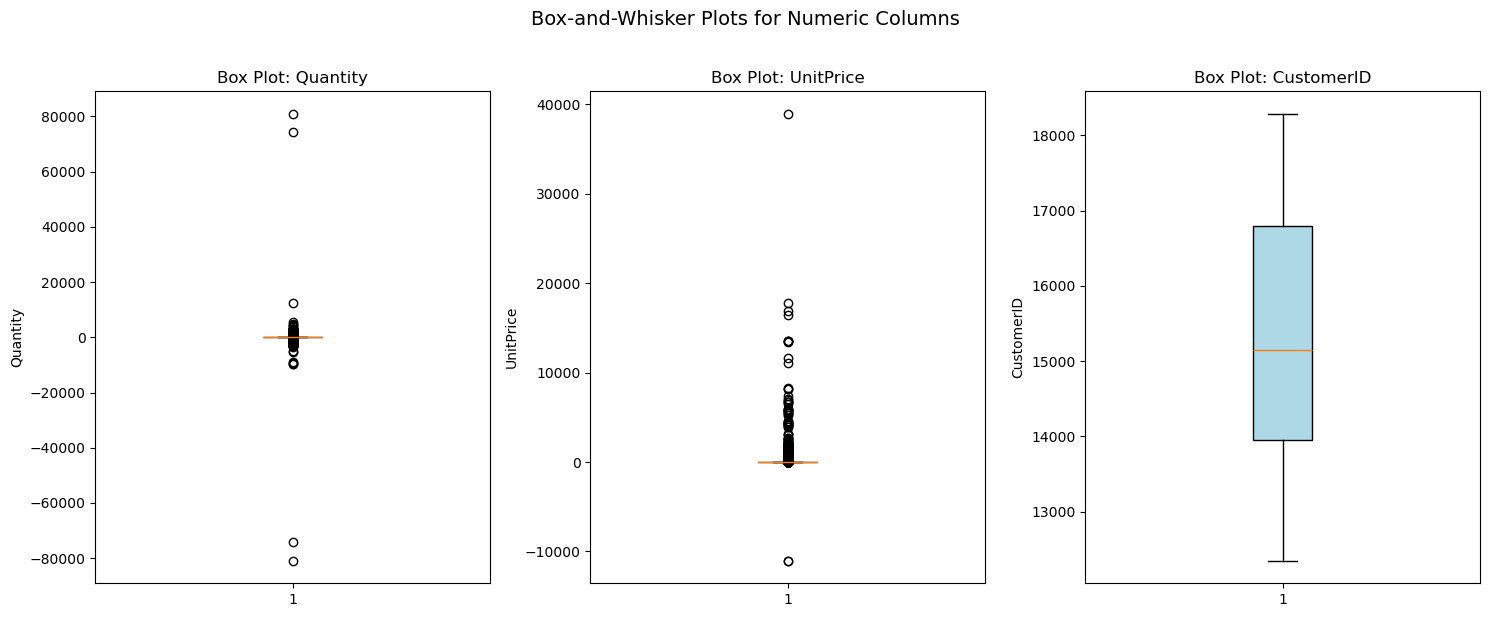

In [26]:
# ==================== BOX-AND-WHISKER PLOT ====================
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 6))
if len(numeric_cols) == 1:
    axes = [axes]
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna().values, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Box Plot: {col}', fontsize=12)
    axes[i].set_ylabel(col)
fig.suptitle('Box-and-Whisker Plots for Numeric Columns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

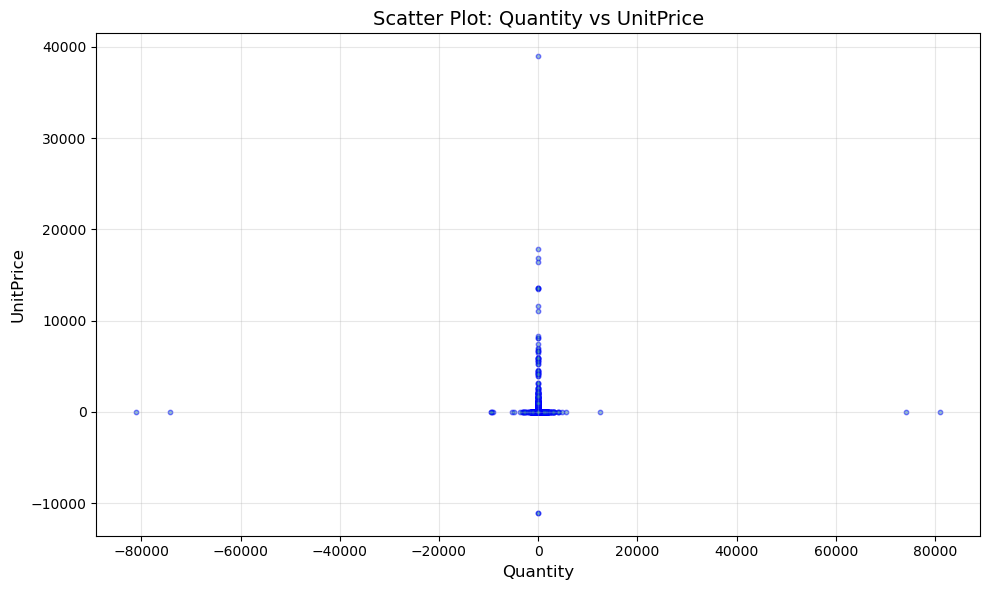

In [27]:
# ==================== SCATTER PLOT ====================
# Scatter plot between Quantity and UnitPrice
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['Quantity'].values, df['UnitPrice'].values, alpha=0.5, edgecolors='blue', s=10)
ax.set_xlabel('Quantity', fontsize=12)
ax.set_ylabel('UnitPrice', fontsize=12)
ax.set_title('Scatter Plot: Quantity vs UnitPrice', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

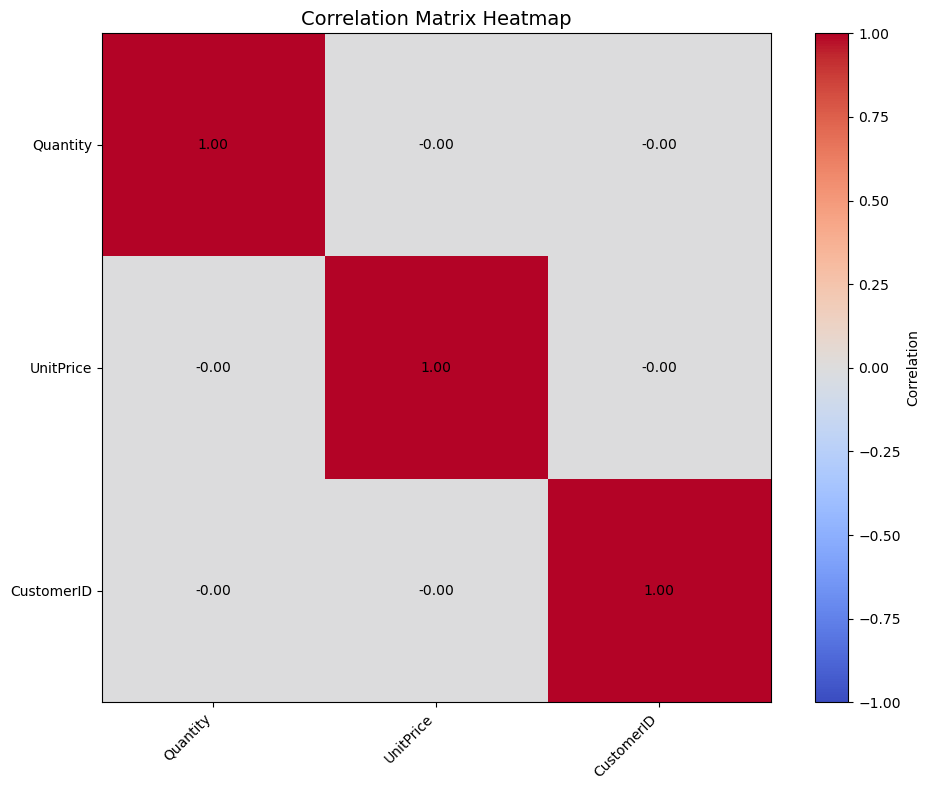

In [28]:
# ==================== CORRELATION MATRIX HEATMAP ====================
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_df.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_df.index)
# Add correlation values as text
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        ax.text(j, i, f'{corr_df.values[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=10)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Correlation Matrix Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## B) Inferential Statistics
### Distributions, Hypothesis Testing (Z-test, T-test, ANOVA), Type I & II Errors

1. NORMAL DISTRIBUTION
   Formula: f(x) = (1/(σ√(2π))) × e^(-(x-μ)²/(2σ²))

  Column: UnitPrice
  Population Mean (μ): 4.6111
  Population Std Dev (σ): 96.7599

  Normal PDF values at key points:
    f(-188.91) = 0.000558
    f(-92.15) = 0.002501
    f(4.61) = 0.004123
    f(101.37) = 0.002501
    f(198.13) = 0.000558


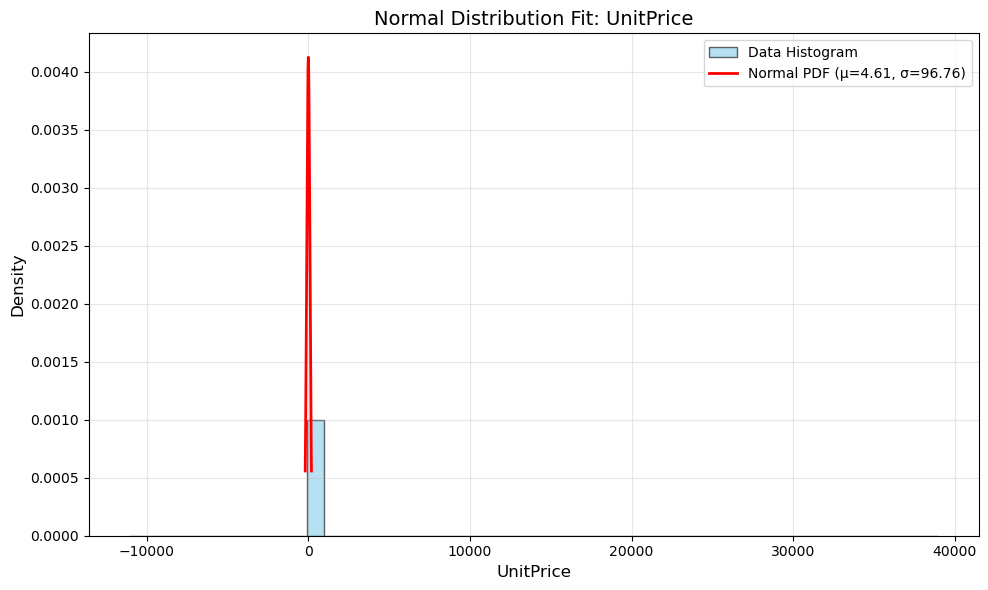

In [29]:
import math

# ==================== NORMAL DISTRIBUTION (Manual) ====================
# Formula: f(x) = (1 / (σ√(2π))) × e^(-(x-μ)²/(2σ²))
print("="*60)
print("1. NORMAL DISTRIBUTION")
print("   Formula: f(x) = (1/(σ√(2π))) × e^(-(x-μ)²/(2σ²))")
print("="*60)

col = 'UnitPrice'
values = df[col].dropna().values
n = len(values)
mu = sum(values) / n
sigma_sq = sum((v - mu) ** 2 for v in values) / (n - 1)
sigma = sigma_sq ** 0.5

print(f"\n  Column: {col}")
print(f"  Population Mean (μ): {mu:.4f}")
print(f"  Population Std Dev (σ): {sigma:.4f}")

# Calculate PDF for a few sample points
sample_points = [mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma]
print(f"\n  Normal PDF values at key points:")
for x in sample_points:
    pdf = (1 / (sigma * (2 * math.pi) ** 0.5)) * math.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    print(f"    f({x:.2f}) = {pdf:.6f}")

# Plot Normal Distribution
x_range = sorted(values)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(values, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Data Histogram')
# Generate PDF curve
x_plot = [mu + (i - 500) * (4 * sigma / 1000) for i in range(1001)]
y_plot = [(1 / (sigma * (2 * math.pi) ** 0.5)) * math.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) for x in x_plot]
ax.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Normal PDF (μ={mu:.2f}, σ={sigma:.2f})')
ax.set_xlabel(col, fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Normal Distribution Fit: {col}', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. POISSON DISTRIBUTION
   Formula: P(X=k) = (λ^k × e^(-λ)) / k!

  Column: Quantity (positive values only)
  λ (mean rate): 10.6553

  Poisson PMF values P(X=k):
    P(X=0) = 0.000024
    P(X=1) = 0.000251
    P(X=2) = 0.001338
    P(X=3) = 0.004754
    P(X=4) = 0.012663
    P(X=5) = 0.026985
    P(X=6) = 0.047922
    P(X=7) = 0.072945
    P(X=8) = 0.097156
    P(X=9) = 0.115025
    P(X=10) = 0.122562
    P(X=11) = 0.118721
    P(X=12) = 0.105417
    P(X=13) = 0.086404
    P(X=14) = 0.065761
    P(X=15) = 0.046713


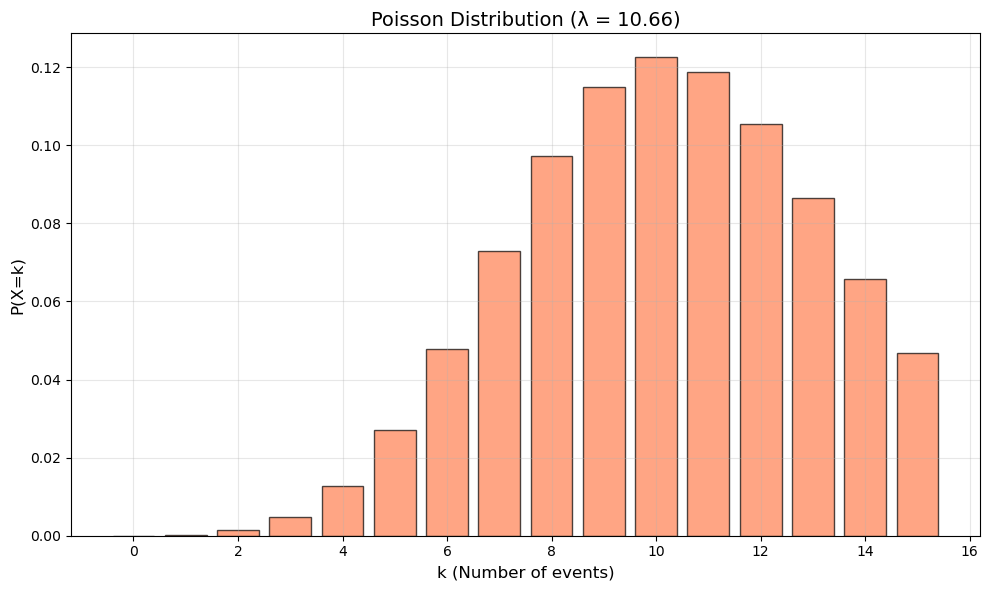

In [30]:
# ==================== POISSON DISTRIBUTION (Manual) ====================
# Formula: P(X=k) = (λ^k × e^(-λ)) / k!
print("="*60)
print("2. POISSON DISTRIBUTION")
print("   Formula: P(X=k) = (λ^k × e^(-λ)) / k!")
print("="*60)

# Using Quantity column - count of items per invoice as Poisson parameter
col = 'Quantity'
values = df[col].dropna().values
# Filter positive quantities for Poisson
pos_values = [v for v in values if v > 0]
lambda_val = sum(pos_values) / len(pos_values)
print(f"\n  Column: {col} (positive values only)")
print(f"  λ (mean rate): {lambda_val:.4f}")

# Manual factorial function
def manual_factorial(n):
    result = 1
    for i in range(2, int(n) + 1):
        result *= i
    return result

# Calculate Poisson PMF for k = 0 to 15
print(f"\n  Poisson PMF values P(X=k):")
k_values = list(range(0, 16))
poisson_pmf = []
for k in k_values:
    pmf = (lambda_val ** k * math.exp(-lambda_val)) / manual_factorial(k)
    poisson_pmf.append(pmf)
    print(f"    P(X={k}) = {pmf:.6f}")

# Plot Poisson Distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(k_values, poisson_pmf, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('k (Number of events)', fontsize=12)
ax.set_ylabel('P(X=k)', fontsize=12)
ax.set_title(f'Poisson Distribution (λ = {lambda_val:.2f})', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# ==================== POPULATION PARAMETERS & SAMPLING ERROR ====================
print("="*60)
print("3. POPULATION PARAMETERS & SAMPLING ERROR")
print("="*60)

col = 'UnitPrice'
population = df[col].dropna().values
N = len(population)
pop_mean = sum(population) / N
pop_var = sum((v - pop_mean) ** 2 for v in population) / N  # Population variance (divide by N)
pop_std = pop_var ** 0.5

print(f"\n  Population Mean (μ): {pop_mean:.4f}")
print(f"  Population Std Dev (σ): {pop_std:.4f}")
print(f"  Population Size (N): {N}")

# Take a random sample
np.random.seed(42)
sample_size = 50
sample_indices = np.random.choice(N, size=sample_size, replace=False)
sample = population[sample_indices]
sample_mean = sum(sample) / sample_size
sampling_error = sample_mean - pop_mean

print(f"\n  Sample Size (n): {sample_size}")
print(f"  Sample Mean (x̄): {sample_mean:.4f}")
print(f"  Sampling Error (x̄ - μ): {sampling_error:.4f}")

# ==================== CONFIDENCE INTERVAL (Manual, Z-based) ====================
# Formula: CI = x̄ ± z × (σ / √n)
print("\n" + "="*60)
print("4. CONFIDENCE INTERVAL (95%)")
print("   Formula: CI = x̄ ± z × (σ / √n)")
print("="*60)

z_95 = 1.96  # z-value for 95% confidence
se = pop_std / (sample_size ** 0.5)
ci_lower = sample_mean - z_95 * se
ci_upper = sample_mean + z_95 * se

print(f"\n  z-value (95% confidence): {z_95}")
print(f"  Standard Error: {se:.4f}")
print(f"  95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"  Population Mean μ = {pop_mean:.4f} {'falls within' if ci_lower <= pop_mean <= ci_upper else 'falls outside'} the CI")

3. POPULATION PARAMETERS & SAMPLING ERROR

  Population Mean (μ): 4.6111
  Population Std Dev (σ): 96.7598
  Population Size (N): 541909

  Sample Size (n): 50
  Sample Mean (x̄): 3.1110
  Sampling Error (x̄ - μ): -1.5001

4. CONFIDENCE INTERVAL (95%)
   Formula: CI = x̄ ± z × (σ / √n)

  z-value (95% confidence): 1.96
  Standard Error: 13.6839
  95% Confidence Interval: (-23.7094, 29.9314)
  Population Mean μ = 4.6111 falls within the CI


In [32]:
# ==================== Z-TEST (Manual) ====================
# Formula: z = (x̄ - μ) / (σ / √n)
# H0: The sample mean equals the population mean
# H1: The sample mean does not equal the population mean
print("="*60)
print("5. Z-TEST (Two-tailed)")
print("   Formula: z = (x̄ - μ) / (σ / √n)")
print("="*60)

col = 'UnitPrice'
population = df[col].dropna().values
N = len(population)
pop_mean = sum(population) / N
pop_std = (sum((v - pop_mean) ** 2 for v in population) / N) ** 0.5

np.random.seed(42)
sample = population[np.random.choice(N, size=50, replace=False)]
n = len(sample)
sample_mean = sum(sample) / n

z_stat = (sample_mean - pop_mean) / (pop_std / (n ** 0.5))

# Manual p-value approximation using the error function
# P(Z > |z|) using complementary error function: p = erfc(|z|/√2)
p_value = math.erfc(abs(z_stat) / (2 ** 0.5))

alpha = 0.05
print(f"\n  H₀: μ_sample = μ_population ({pop_mean:.4f})")
print(f"  H₁: μ_sample ≠ μ_population")
print(f"\n  Sample Mean (x̄): {sample_mean:.4f}")
print(f"  Population Mean (μ): {pop_mean:.4f}")
print(f"  Population Std Dev (σ): {pop_std:.4f}")
print(f"  Sample Size (n): {n}")
print(f"  Z-statistic: {z_stat:.4f}")
print(f"  P-value (two-tailed): {p_value:.6f}")
print(f"  Significance Level (α): {alpha}")
print(f"\n  Decision: {'Reject H₀' if p_value < alpha else 'Fail to Reject H₀'}")
print(f"  Interpretation: {'There IS a significant difference' if p_value < alpha else 'There is NO significant difference'} between sample and population means.")

5. Z-TEST (Two-tailed)
   Formula: z = (x̄ - μ) / (σ / √n)

  H₀: μ_sample = μ_population (4.6111)
  H₁: μ_sample ≠ μ_population

  Sample Mean (x̄): 3.1110
  Population Mean (μ): 4.6111
  Population Std Dev (σ): 96.7598
  Sample Size (n): 50
  Z-statistic: -0.1096
  P-value (two-tailed): 0.912706
  Significance Level (α): 0.05

  Decision: Fail to Reject H₀
  Interpretation: There is NO significant difference between sample and population means.


In [33]:
# ==================== T-TEST (Manual) ====================
# Formula: t = (x̄ - μ) / (s / √n)  where s is sample std dev
# H0: Sample mean = hypothesized mean
# H1: Sample mean ≠ hypothesized mean
print("="*60)
print("6. T-TEST (One-sample, Two-tailed)")
print("   Formula: t = (x̄ - μ₀) / (s / √n)")
print("="*60)

col = 'UnitPrice'
population = df[col].dropna().values
pop_mean = sum(population) / len(population)

np.random.seed(42)
sample = population[np.random.choice(len(population), size=30, replace=False)]
n = len(sample)
sample_mean = sum(sample) / n

# Sample standard deviation (using n-1)
sample_var = sum((v - sample_mean) ** 2 for v in sample) / (n - 1)
sample_std = sample_var ** 0.5

t_stat = (sample_mean - pop_mean) / (sample_std / (n ** 0.5))
df_t = n - 1  # degrees of freedom

# Approximate p-value for t-distribution using scipy (for accuracy)
# Manual approximation: for large df, t ≈ z
p_value_t = math.erfc(abs(t_stat) / (2 ** 0.5))  # approximation for large df

alpha = 0.05
print(f"\n  H₀: μ_sample = μ₀ ({pop_mean:.4f})")
print(f"  H₁: μ_sample ≠ μ₀")
print(f"\n  Sample Mean (x̄): {sample_mean:.4f}")
print(f"  Hypothesized Mean (μ₀): {pop_mean:.4f}")
print(f"  Sample Std Dev (s): {sample_std:.4f}")
print(f"  Sample Size (n): {n}")
print(f"  Degrees of Freedom (df): {df_t}")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value (approx, two-tailed): {p_value_t:.6f}")
print(f"  Significance Level (α): {alpha}")
print(f"\n  Decision: {'Reject H₀' if p_value_t < alpha else 'Fail to Reject H₀'}")
print(f"  Interpretation: {'There IS a significant difference' if p_value_t < alpha else 'There is NO significant difference'} between sample mean and hypothesized mean.")

6. T-TEST (One-sample, Two-tailed)
   Formula: t = (x̄ - μ₀) / (s / √n)

  H₀: μ_sample = μ₀ (4.6111)
  H₁: μ_sample ≠ μ₀

  Sample Mean (x̄): 3.4127
  Hypothesized Mean (μ₀): 4.6111
  Sample Std Dev (s): 3.0661
  Sample Size (n): 30
  Degrees of Freedom (df): 29
  T-statistic: -2.1409
  P-value (approx, two-tailed): 0.032285
  Significance Level (α): 0.05

  Decision: Reject H₀
  Interpretation: There IS a significant difference between sample mean and hypothesized mean.


In [34]:
# ==================== TYPE I AND TYPE II ERRORS ====================
print("="*60)
print("7. TYPE I AND TYPE II ERRORS")
print("="*60)

print("""
  TYPE I ERROR (α - False Positive):
  ----------------------------------
  - Rejecting a TRUE null hypothesis
  - Probability = α (significance level, typically 0.05)
  - Example: Concluding that a customer segment differs in spending
    when it actually does not.
  
  TYPE II ERROR (β - False Negative):
  -----------------------------------
  - Failing to reject a FALSE null hypothesis
  - Probability = β
  - Power of test = 1 - β
  - Example: Failing to detect a real difference in customer
    spending patterns between segments.
""")

# Demonstrate with simulation
print("  Simulation: Running 1000 Z-tests on random samples from the SAME population")
print("  (H₀ is TRUE, so any rejection is a Type I Error)")

alpha = 0.05
type1_errors = 0
n_simulations = 1000
np.random.seed(42)

col = 'UnitPrice'
population = df[col].dropna().values
N_pop = len(population)
pop_mean = sum(population) / N_pop
pop_std = (sum((v - pop_mean) ** 2 for v in population) / N_pop) ** 0.5

for _ in range(n_simulations):
    sample = population[np.random.choice(N_pop, size=50, replace=False)]
    s_mean = sum(sample) / len(sample)
    z = (s_mean - pop_mean) / (pop_std / (len(sample) ** 0.5))
    p = math.erfc(abs(z) / (2 ** 0.5))
    if p < alpha:
        type1_errors += 1

print(f"\n  Number of Type I Errors: {type1_errors} out of {n_simulations}")
print(f"  Observed Type I Error Rate: {type1_errors / n_simulations:.4f}")
print(f"  Expected Type I Error Rate (α): {alpha}")

7. TYPE I AND TYPE II ERRORS

  TYPE I ERROR (α - False Positive):
  ----------------------------------
  - Rejecting a TRUE null hypothesis
  - Probability = α (significance level, typically 0.05)
  - Example: Concluding that a customer segment differs in spending
    when it actually does not.
  
  TYPE II ERROR (β - False Negative):
  -----------------------------------
  - Failing to reject a FALSE null hypothesis
  - Probability = β
  - Power of test = 1 - β
  - Example: Failing to detect a real difference in customer
    spending patterns between segments.

  Simulation: Running 1000 Z-tests on random samples from the SAME population
  (H₀ is TRUE, so any rejection is a Type I Error)

  Number of Type I Errors: 4 out of 1000
  Observed Type I Error Rate: 0.0040
  Expected Type I Error Rate (α): 0.05


In [35]:
# ==================== ANOVA (One-Way, Manual) ====================
# Formula: F = MS_between / MS_within
#   SS_between = Σ nj × (x̄j - x̄)²
#   SS_within  = Σ Σ (xij - x̄j)²
#   MS_between = SS_between / (k-1)
#   MS_within  = SS_within  / (N-k)
#   F = MS_between / MS_within
print("="*60)
print("8. ONE-WAY ANOVA (Manual)")
print("   Formula: F = MS_between / MS_within")
print("   Comparing UnitPrice across top 3 Countries")
print("="*60)

# Get top 3 countries by transaction count
country_counts = {}
for c in df['Country'].dropna():
    country_counts[c] = country_counts.get(c, 0) + 1
top_countries = sorted(country_counts.items(), key=lambda x: x[1], reverse=True)[:3]
top_country_names = [c[0] for c in top_countries]
print(f"\n  Groups (Top 3 Countries): {top_country_names}")

# Create groups
groups = {}
for country in top_country_names:
    mask = df['Country'] == country
    groups[country] = df.loc[mask, 'UnitPrice'].dropna().values

# Grand mean
all_values = []
for country in top_country_names:
    all_values.extend(groups[country])
N_total = len(all_values)
grand_mean = sum(all_values) / N_total
k = len(groups)  # number of groups

print(f"  Grand Mean: {grand_mean:.4f}")
print(f"  Number of Groups (k): {k}")
print(f"  Total Observations (N): {N_total}")

# SS Between
ss_between = 0
for country in top_country_names:
    g = groups[country]
    nj = len(g)
    group_mean = sum(g) / nj
    ss_between += nj * (group_mean - grand_mean) ** 2
    print(f"  Group '{country}': n={nj}, mean={group_mean:.4f}")

# SS Within
ss_within = 0
for country in top_country_names:
    g = groups[country]
    group_mean = sum(g) / len(g)
    for v in g:
        ss_within += (v - group_mean) ** 2

# Degrees of freedom
df_between = k - 1
df_within = N_total - k

# Mean Squares
ms_between = ss_between / df_between
ms_within = ss_within / df_within

# F-statistic
f_stat = ms_between / ms_within

print(f"\n  SS_between: {ss_between:.4f}")
print(f"  SS_within:  {ss_within:.4f}")
print(f"  df_between: {df_between}")
print(f"  df_within:  {df_within}")
print(f"  MS_between: {ms_between:.4f}")
print(f"  MS_within:  {ms_within:.4f}")
print(f"  F-statistic: {f_stat:.4f}")

# Use scipy for critical F-value for comparison
f_critical = stats.f.ppf(1 - 0.05, df_between, df_within)
f_p_value = 1 - stats.f.cdf(f_stat, df_between, df_within)

print(f"\n  F-critical (α=0.05): {f_critical:.4f}")
print(f"  P-value: {f_p_value:.6f}")
print(f"\n  Decision: {'Reject H₀' if f_stat > f_critical else 'Fail to Reject H₀'}")
print(f"  Interpretation: {'There IS a significant difference' if f_stat > f_critical else 'There is NO significant difference'} in UnitPrice across the top 3 countries.")

8. ONE-WAY ANOVA (Manual)
   Formula: F = MS_between / MS_within
   Comparing UnitPrice across top 3 Countries

  Groups (Top 3 Countries): ['United Kingdom', 'Germany', 'France']
  Grand Mean: 4.5302
  Number of Groups (k): 3
  Total Observations (N): 513530
  Group 'United Kingdom': n=495478, mean=4.5324
  Group 'Germany': n=9495, mean=3.9669
  Group 'France': n=8557, mean=5.0289

  SS_between: 5142.7882
  SS_within:  4944399471.8714
  df_between: 2
  df_within:  513527
  MS_between: 2571.3941
  MS_within:  9628.3145
  F-statistic: 0.2671

  F-critical (α=0.05): 2.9957
  P-value: 0.765623

  Decision: Fail to Reject H₀
  Interpretation: There is NO significant difference in UnitPrice across the top 3 countries.


## CONCLUSION

In this experiment, we explored the **Online Retail Dataset** for Customer Segmentation and performed:

### A) Descriptive Statistics (all computed using manual formulas):
- Central Tendency: Mean, Median, Mode
- Dispersion: Range, Variance, Standard Deviation, IQR, Coefficient of Variation
- Position: Q1, Q3, Percentiles
- Shape: Skewness, Kurtosis
- Other: SE of Mean, N Missing, Cumulative N, Percent, Trimmed Mean, Sum of Squares, Correlation
- Visualizations: Box-and-Whisker Plots, Scatter Plots, Correlation Matrix Heatmap

### B) Inferential Statistics:
- **Distributions**: Normal Distribution, Poisson Distribution with manual PDF/PMF computation
- **Population Parameters & Sampling Error**: Demonstrated difference between sample and population means
- **Confidence Intervals**: 95% CI computed manually using Z-value
- **Hypothesis Testing**: Z-test and T-test with manual formula computation
- **Type I and Type II Errors**: Explained and demonstrated via simulation
- **ANOVA**: One-way ANOVA comparing UnitPrice across top 3 countries